In [9]:
import matplotlib.pyplot as plt
# plt.style.use('seaborn-v0_8')
plt.style.use('ggplot')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

import matplotlib.pylab as plt
import pickle as pkl
import numpy as np
from dataclasses import dataclass
from collections import Counter
from scipy import stats

In [10]:
@dataclass
class Args:
    seed: int=0
    alpha: float=0.05
    n_persons: int=1000
    quantity_on_hand: int = 0
    worst_response: bool=False
    softmax: bool=False
    n_response: int=8


args = Args()

In [11]:
# SAVE EXP DATA
with open("exp_data.pkl", "rb") as f:
    (alpha_list, exp_data, data) = pkl.load(f)

0.01 0.5 49.550000000000004
0.01 0.75 93.60000000000001
0.01 0.95 99.80000000000001
[0.5, 0.75, 0.95] [np.float64(49.550000000000004), np.float64(93.60000000000001), np.float64(99.80000000000001)]
['$\\leq 2$', '$3$', '$4$', '$5$', '$\\geq 6$'] [0.058 0.186 0.283 0.289 0.182]
0.05 0.5 42.6
0.05 0.75 89.60000000000001
0.05 0.95 99.80000000000001
[0.5, 0.75, 0.95] [np.float64(42.6), np.float64(89.60000000000001), np.float64(99.80000000000001)]
['$\\leq 2$', '$3$', '$4$', '$5$', '$\\geq 6$'] [0.053 0.167 0.277 0.287 0.214]
0.1 0.5 34.0
0.1 0.75 83.0
0.1 0.95 99.7
[0.5, 0.75, 0.95] [np.float64(34.0), np.float64(83.0), np.float64(99.7)]
['$\\leq 2$', '$3$', '$4$', '$5$', '$\\geq 6$'] [0.066 0.173 0.275 0.292 0.192]
1.0 0.5 14.15
1.0 0.75 55.75
1.0 0.95 85.15
[0.5, 0.75, 0.95] [np.float64(14.15), np.float64(55.75), np.float64(85.15)]
['$\\leq 2$', '$3$', '$4$', '$5$', '$\\geq 6$'] [0.353 0.33  0.205 0.057 0.036]


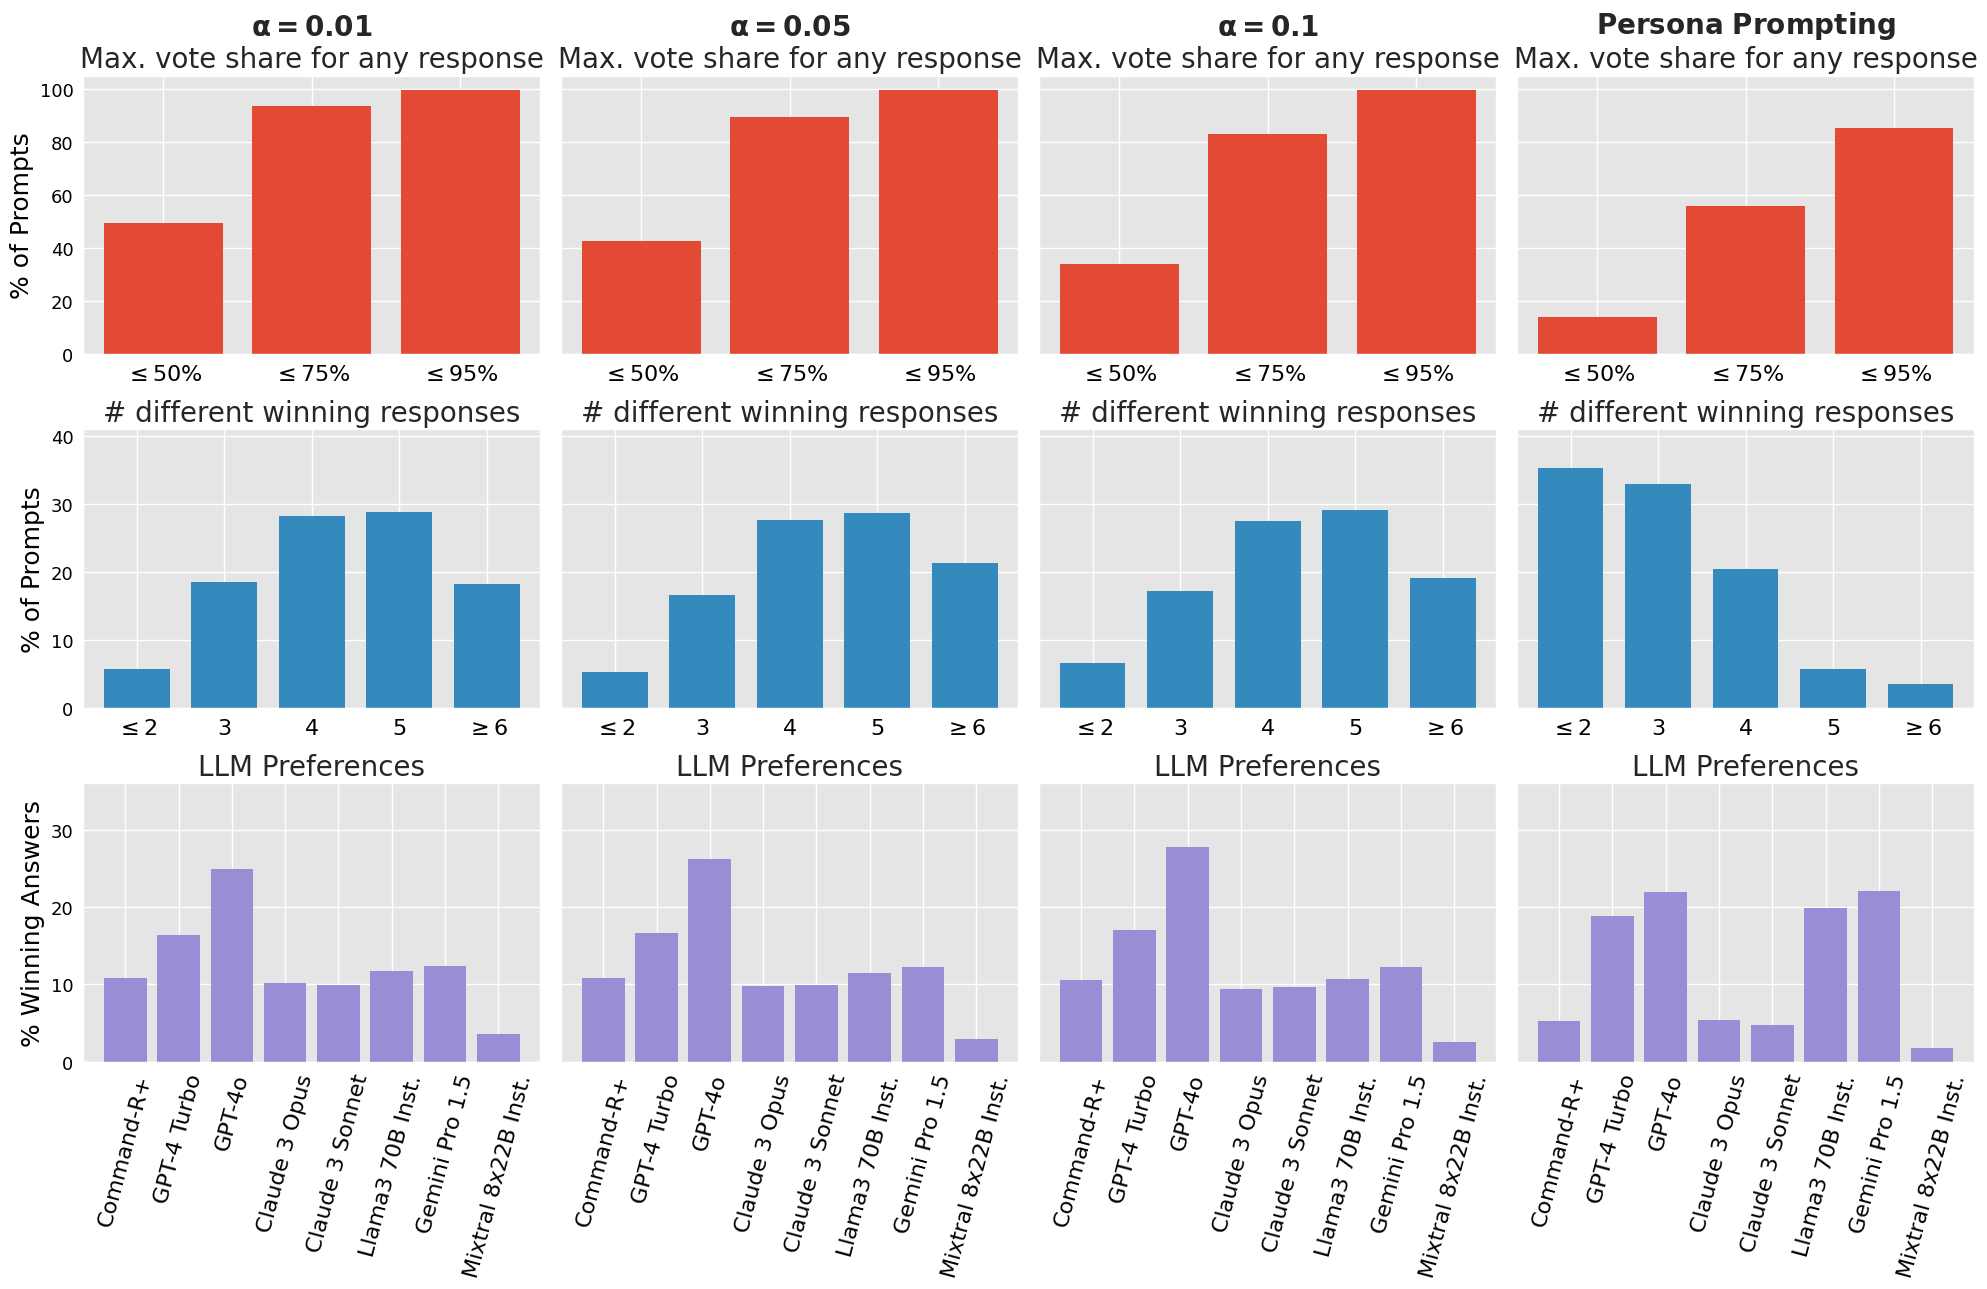

In [20]:
models_map = {
    'command-r-plus': "Command-R+", 
    'gpt-4-turbo': "GPT-4 Turbo", 
    'gpt-4o': "GPT-4o", 
    'claude-3-opus': "Claude 3 Opus", 
    'claude-3-sonnet': "Claude 3 Sonnet", 
    'llama-3-70b-instruct': "Llama3 70B Inst.", 
    'gemini-pro-1.5': "Gemini Pro 1.5", 
    'mixtral-8x22b-instruct': "Mixtral 8x22B Inst."
}

models = []
for i in range(args.n_response):
    model_name = data.iloc[0]["response_{}_model".format(i+1)]
    models.append(model_name)
    assert data.iloc[0]["response_{}_model".format(i+1)] == data.iloc[1]["response_{}_model".format(i+1)]


plt.rcParams["figure.figsize"] = (20,13)
fig, axs = plt.subplots(3,len(alpha_list))

for i, alpha in enumerate(alpha_list):
    a_data = exp_data[str(alpha)]
    a_persons = a_data["persons"]
    a_choices = a_data["choices"]


    max_counts = []
    diff_counts = []
    for j in range(a_choices.shape[0]):
        counts = Counter(a_choices[j])
        max_count = np.max(list(counts.values()))
        max_counts.append(max_count)
        diff_counts.append(len(counts))

    max_counts = np.array(max_counts)
    max_pct = max_counts/a_persons.shape[0]
    diff_counts = np.array(diff_counts)

    ############################################
    # Top vote share CDF
    ############################################

    max_pct_count = Counter(max_pct)
    
    vals = []
    qs = [0.5, 0.75, 0.95]
    q_labels = [
        r"$\leq 50\%$", 
        r"$\leq 75\%$", 
        r"$\leq 95\%$", 
    ]
    for q in qs:
        s = stats.percentileofscore(max_pct, q)
        print(alpha, q, s)
        vals.append(s)

    print(qs, vals)
    axs[0,i].bar(q_labels, vals)
    axs[0,i].tick_params(axis='x', labelsize=16)
    axs[0,i].set_ylim(0.0, 105.0)

    if alpha != 1.0:
        # axs[0, i].set_title(r"$\bf{\alpha={}}$".format(alpha)+"\nMax vote share", fontsize=18)
        axs[0, i].set_title(rf'$\bf{{\alpha={alpha}}}$'+'\nMax. vote share for any response', fontsize=20)
    else:
        # axs[0, i].set_title("Persona Prompting\nMax vote share", fontsize=18)
        axs[0, i].set_title(rf'$\bf{{Persona\ Prompting}}$'+'\nMax. vote share for any response', fontsize=20)
    
    ############################################
    # No. different winning
    ############################################

    dc_count = Counter(diff_counts)
    X = list(dc_count.keys())
    y = np.array(list(dc_count.values()))
    X, y = zip(*sorted(zip(X, y)))
    y = np.array(y)/len(diff_counts)
    

    X = [r"$\leq 2$", r"$3$", r"$4$", r"$5$", r"$\geq 6$"]
    y = np.array([np.sum(y[1:3])]+list(y)[3:6]+[np.sum(y[6:])])

    print(X, y)

    axs[1,i].bar(X, y*100, width = 0.75, color=pal[1]) 

    axs[1,i].set_xticks(X)
    axs[1,i].tick_params(axis='y')
    axs[1,i].tick_params(axis='x', labelsize=16)
    axs[1,i].set_title("# different winning responses", fontsize=20)
    
    ############################################
    # Best LLMs
    ############################################

    unique, counts = np.unique(a_choices, return_counts=True)
    models_list = [models[u].split("/")[-1].split(":")[0] for u in unique]

    total_items = np.sum(np.ones_like(a_choices))

    pcts = counts/total_items
    axs[2,i].bar([models[u] for u in unique], pcts*100, color=pal[2]) 
    
    axs[2,i].set_title(r"LLM Preferences", fontsize=20)
    axs[2,i].set_xticks(unique, [models_map[m] for m in models_list], rotation=75, size=16)
    axs[2,i].tick_params(axis='x')
    axs[2,i].tick_params(axis='y')

    axs[1,i].set_ylim(0.0, 41)
    axs[2,i].set_ylim(0.0, 36)

    if i != 0:
        axs[0,i].set_yticklabels([])
        axs[1,i].set_yticklabels([])
        axs[2,i].set_yticklabels([])

    axs[0,i].tick_params(axis='y', labelsize=13)
    axs[1,i].tick_params(axis='y', labelsize=13)
    axs[2,i].tick_params(axis='y', labelsize=13)

axs[0,0].set_ylabel(r"% of Prompts", fontsize=18, color="k")
axs[1,0].set_ylabel(r"% of Prompts", fontsize=18, color="k")
axs[2,0].set_ylabel(r"% Winning Answers", fontsize=18, color="k")

for i in range(3):
    for j in range(4):
        axs[i,j].tick_params("y", labelcolor="k")
        axs[i,j].tick_params("x", labelcolor="k")

fig.tight_layout()
plt.savefig("../plots/persona_prompting_comparison.png", bbox_inches="tight", dpi=300)
plt.show()